In [9]:
from few.utils.Extra_for_project.flux_calculations import (compare, kerrecceqA, nex, 
nex_pedot, few_pedot, nex_ELdot, few_ELdot)
import numpy as np
import matplotlib.pyplot as plt
from few.utils.geodesic import get_separatrix
from few.utils.mappings.kerrecceq import DELTAPMAX_REGIONC,DELTAPMIN_REGIONC

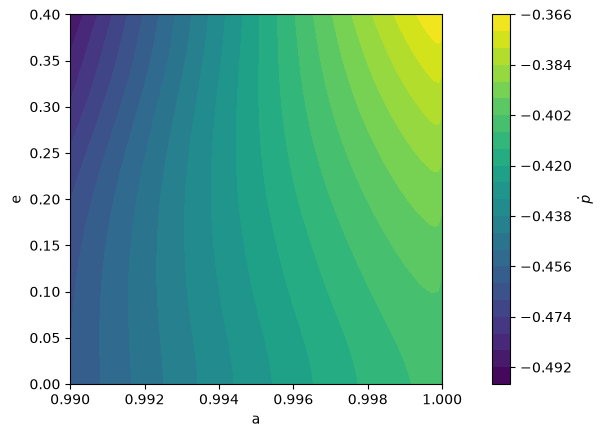

In [10]:
p=2
n1,n2 =100,100
a = np.linspace(0.99, 1-10**(-12), n1)
e = np.linspace(0, 0.4, n2)
A, E = np.meshgrid(a, e)

Z =nex_pedot(A.flatten(),(np.ones_like(A)*p).flatten(),E.flatten(),np.ones_like(E).flatten())#get_separatrix(A.flatten(),E.flatten(),np.ones_like(A).flatten()) # nex_pedot(A,np.ones_like(A)*6,E,np.ones_like(E))
Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

fig, ax = plt.subplots()

cf1 = ax.contourf(A, E, Z_p, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax, label=r"$\dot{p}$",pad = 0.1)

ax.set_xlabel("a")
ax.set_ylabel("e")



plt.show()

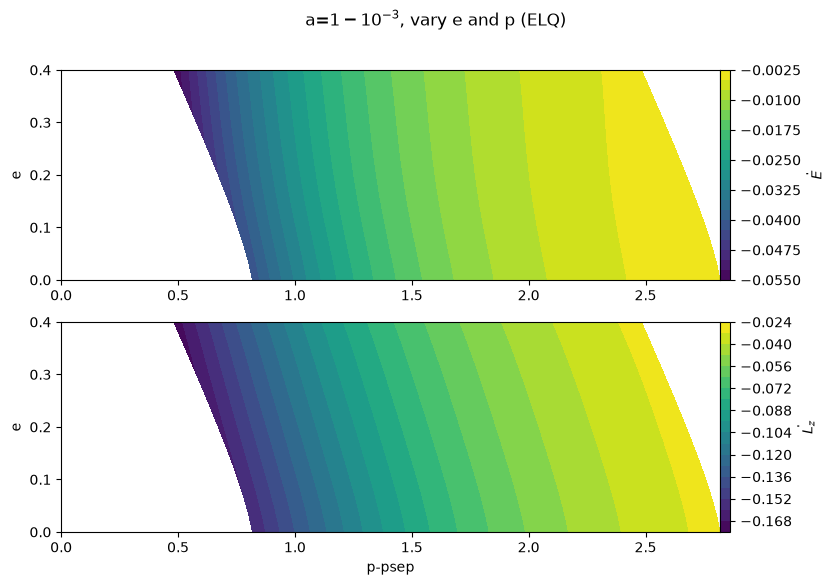

In [20]:
x=1
n=3
a=1-10**(-n)
n1,n2 =1000,1000

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(2,4,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = nex_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())   #flux takes apex, spits out pdot, edot, Edot,Ldot

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{E}$",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{L_{z}}$",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, vary e and p (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")

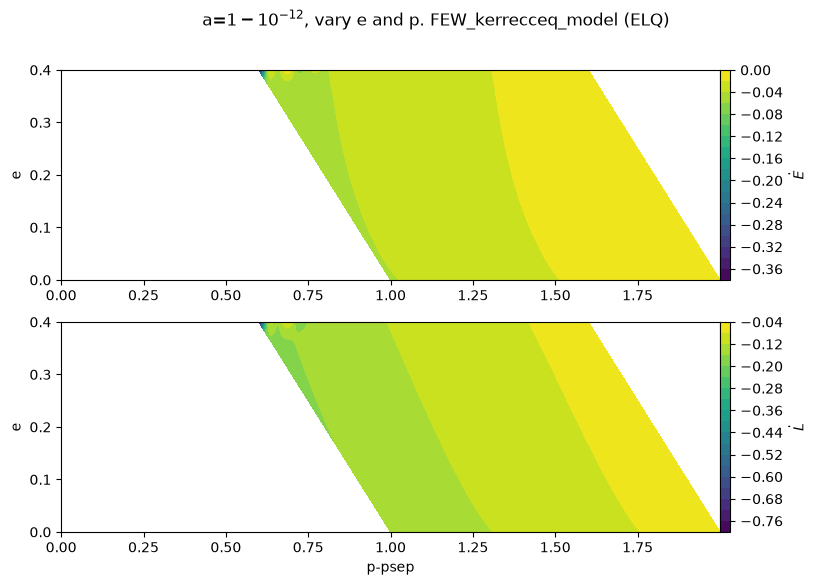

In [21]:
x=1
n=12
a=1-10**(-n)
n1,n2 =1000,1000

e = np.linspace(0, 0.4, n1)
psep_min = min(get_separatrix(a,e,x))
p= np.linspace(2,3,n2) #######Change  pmin to further out to see behaviour away from separatrix better

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z = few_ELdot(A.flatten(),P.flatten(),E.flatten(),X.flatten())

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p = Z[0].reshape(n1,n2)
Z_e = Z[1].reshape(n1,n2)

Zp_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p, np.nan)
Ze_masked = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e, np.nan)


fig, ax = plt.subplots(2,1,figsize = (10,6))

cf1 = ax[0].contourf(P-PSEP, E, Zp_masked, levels=20, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"$\dot{E}$",pad = 0)
cf2 = ax[1].contourf(P-PSEP, E, Ze_masked, levels=20, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"$\dot{L}$",pad = 0)

ax[0].set_xlim(0)
ax[1].set_xlim(0)

ax[0].set_ylabel("e")

ax[1].set_xlabel("p-psep")
ax[1].set_ylabel("e")

#ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")
plt.suptitle(rf"a=$1-10^{{-{n}}}$, vary e and p. FEW_kerrecceq_model (ELQ)")
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_FEW_ELQ.png", dpi=300, bbox_inches="tight")

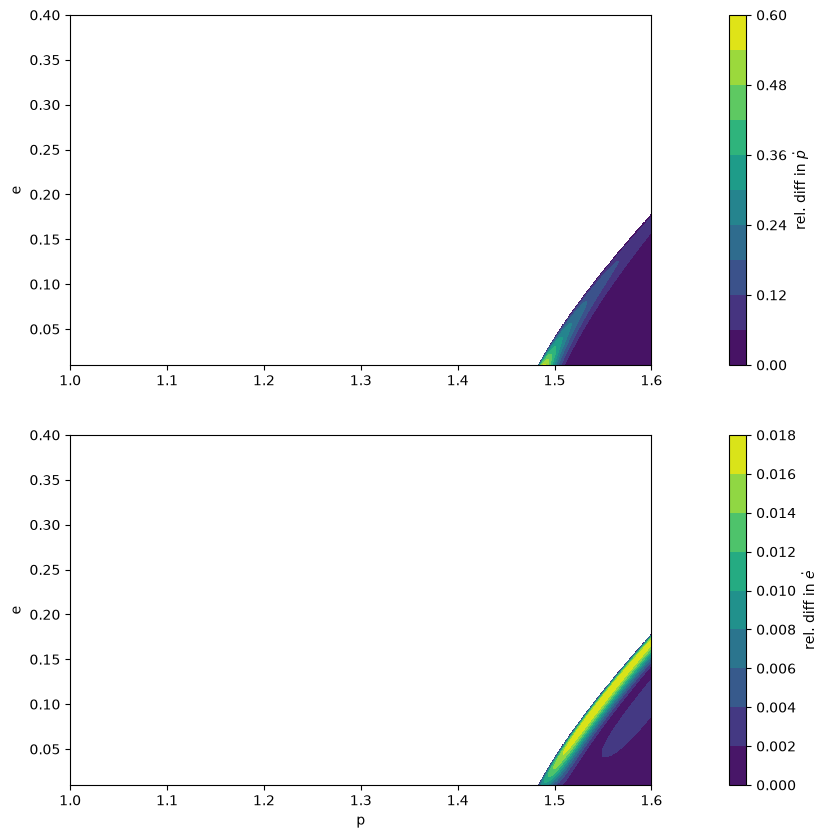

In [15]:
x=1
a=1-10**(-2)
n1,n2 =1000,1000

e = np.linspace(0.01, 0.4, n1)
p= np.linspace(1,1.6,n2)

E, P = np.meshgrid(e, p)
A= np.ones_like(P)*a
X= np.ones_like(P)

Z_few = (few_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten()))
Z_nex = (nex_pedot(A.flatten(),P.flatten(),E.flatten(),X.flatten()))

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)

Z_p_few = Z_few[0].reshape(n1,n2)
Z_e_few = Z_few[1].reshape(n1,n2)
Z_p_nex = Z_nex[0].reshape(n1,n2)
Z_e_nex = Z_nex[1].reshape(n1,n2)

Zp_masked_few = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_few, np.nan)
Ze_masked_few = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_few, np.nan)
Zp_masked_nex = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_p_nex, np.nan)
Ze_masked_nex = np.where(P > PSEP+np.ones_like(PSEP)*DELTAPMIN_REGIONC, Z_e_nex, np.nan)

rel_diff_p = np.abs((Zp_masked_few-Zp_masked_nex))#/(Zp_masked_few))
rel_diff_e = np.abs((Ze_masked_few-Ze_masked_nex))#/(Ze_masked_few))

fig, ax = plt.subplots(2,1,figsize = (10,10))

cf1 = ax[0].contourf(P, E, rel_diff_p, levels=10, cmap="viridis")
fig.colorbar(cf1, ax=ax[0], label=r"rel. diff in $ \dot{p}$",pad = 0.1)

cf2 = ax[1].contourf(P, E, rel_diff_e, levels=10, cmap="viridis")
fig.colorbar(cf2, ax=ax[1], label=r"rel. diff in $ \dot{e}$",pad = 0.1)


#ax[0].set_xlabel("p")
ax[0].set_ylabel("e")
ax[1].set_xlabel("p")
ax[1].set_ylabel("e")

ax[0].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
ax[1].plot(get_separatrix(np.ones_like(e)*a,e,np.ones_like(e)),e,color="red")
#ax.fill_between(get_separatrix(a,np.ones_like(a)*e,np.ones_like(a)*1)+DELTAPMIN_REGIONC, 0.99, a, color="grey", alpha=0.3, hatch="//")

plt.show()